# Text Generation with Dynamic Neural Network

This notebook demonstrates building a generative model using DynamicNetwork for next-word prediction.

## Features:
- **Bilingual**: English + Arabic text generation
- **5 Pattern Types**: Associations, Categories, Sequences, Templates, Analogies
- **100K Training Records**: 80K train / 10K val / 10K test
- **First Principles Design**: Patterns designed for BoW + softmax architecture

## 1. Setup and Imports

In [ ]:
import sys
import os
import numpy as np
import time

# Add paths
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
src_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, os.path.join(project_root, 'python'))
sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Source dir: {src_dir}")

Project root: c:\Workspaces\dynamic_nn
Source dir: c:\Workspaces\dynamic_nn\notebooks\gen_model


In [ ]:
# Import our modules
from src.data_generator import GenerativeDataGenerator, generate_dataset, get_data_statistics
from src.tokenizer import GenerativeTokenizer, normalize_features, one_hot_encode
from src.trainer import GenerativeTrainer
from src.evaluator import GenerativeEvaluator

# Import DynamicNetwork for visualization
from pydnn import DynamicNetwork
from pydnn.visualization import auto_generate_plots

print("All imports successful!")

All imports successful!


## 2. Generate Training Data (100K Samples)

In [ ]:
# Configuration
NUM_SAMPLES = 100000
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
SEED = 87
EN_RATIO = 0.5  

DATA_DIR = "./"  # Save in same directory as notebook

print(f"Generating {NUM_SAMPLES:,} samples...")
print(f"  Train: {int(NUM_SAMPLES * TRAIN_RATIO):,}")
print(f"  Val:   {int(NUM_SAMPLES * VAL_RATIO):,}")
print(f"  Test:  {int(NUM_SAMPLES * (1 - TRAIN_RATIO - VAL_RATIO)):,}")

Generating 100,000 samples...
  Train: 80,000
  Val:   10,000
  Test:  9,999


In [ ]:
# Generate dataset
start_time = time.time()

train_file, val_file, test_file = generate_dataset(
    num_samples=NUM_SAMPLES,
    output_dir=DATA_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    en_ratio=EN_RATIO
)

elapsed = time.time() - start_time
print(f"\nData generation completed in {elapsed:.2f}s")

Generating 100,000 samples...
Generated 100,000 samples
Training samples: 80,000 -> ./train.csv
Validation samples: 10,000 -> ./val.csv
Test samples: 10,000 -> ./test.csv

Data generation completed in 0.63s


## 3. Load and Explore Data

In [ ]:
# Load data
generator = GenerativeDataGenerator(seed=SEED)

train_inputs, train_outputs, train_patterns, train_langs = generator.load_from_csv(train_file)
val_inputs, val_outputs, val_patterns, val_langs = generator.load_from_csv(val_file)
test_inputs, test_outputs, test_patterns, test_langs = generator.load_from_csv(test_file)

print(f"Loaded data:")
print(f"  Train: {len(train_inputs):,} samples")
print(f"  Val:   {len(val_inputs):,} samples")
print(f"  Test:  {len(test_inputs):,} samples")

Loaded data:
  Train: 80,000 samples
  Val:   10,000 samples
  Test:  10,000 samples


In [ ]:
# Data statistics
stats = get_data_statistics(train_inputs, train_outputs, train_patterns, train_langs)

print("\nTraining Data Statistics:")
print(f"  Total samples: {stats['total_samples']:,}")
print(f"  Unique inputs: {stats['unique_inputs']:,}")
print(f"  Unique outputs: {stats['unique_outputs']:,}")
print(f"  Avg input words: {stats['avg_input_words']:.2f}")

print("\nPattern Distribution:")
for pattern, count in sorted(stats['pattern_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {pattern:15s}: {count:,} ({pct:.1f}%)")

print("\nLanguage Distribution:")
for lang, count in sorted(stats['language_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {lang:15s}: {count:,} ({pct:.1f}%)")


Training Data Statistics:
  Total samples: 80,000
  Unique inputs: 10,478
  Unique outputs: 350
  Avg input words: 3.10

Pattern Distribution:
  analogy        : 16,010 (20.0%)
  association    : 16,016 (20.0%)
  category       : 16,050 (20.1%)
  sequence       : 15,919 (19.9%)
  template       : 16,005 (20.0%)

Language Distribution:
  ar             : 39,980 (50.0%)
  en             : 40,020 (50.0%)


In [ ]:
# Show sample data for each pattern type
print("\nSample Data by Pattern Type:")
print("=" * 70)

shown_patterns = set()
for i in range(len(train_inputs)):
    pattern = train_patterns[i]
    if pattern not in shown_patterns:
        print(f"\n{pattern.upper()}:")
        # Show 2 examples per pattern (1 EN, 1 AR if available)
        count = 0
        for j in range(i, min(i + 100, len(train_inputs))):
            if train_patterns[j] == pattern:
                print(f"  [{train_langs[j]}] '{train_inputs[j]}' -> '{train_outputs[j]}'")
                count += 1
                if count >= 4:
                    break
        shown_patterns.add(pattern)
    if len(shown_patterns) >= 5:
        break


Sample Data by Pattern Type:

SEQUENCE:
  [en] 'three four five' -> 'six'
  [ar] 'سبعة ثمانية تسعة' -> 'عشرة'
  [en] 'four six eight' -> 'ten'
  [ar] 'رابع خامس سادس' -> 'سابع'

TEMPLATE:
  [ar] 'الكلب الكبير هو' -> 'قوي'
  [en] 'the slow progress is' -> 'steady'
  [ar] 'الشمس الحار هو' -> 'ساطعة'
  [en] 'the slow progress is' -> 'steady'

ANALOGY:
  [en] 'husband man woman' -> 'wife'
  [ar] 'ملكة امرأة رجل' -> 'ملك'
  [ar] 'عمة امرأة رجل' -> 'عم'
  [ar] 'ابنة انثى ذكر' -> 'ابن'

CATEGORY:
  [en] 'food bread salad' -> 'meat'
  [ar] 'لون برتقالي احمر اسود' -> 'ابيض'
  [en] 'body foot eye leg finger' -> 'hand'
  [ar] 'حيوان سمكة قط حصان' -> 'فيل'

ASSOCIATION:
  [ar] 'لون بني' -> 'تراب'
  [en] 'color black' -> 'night'
  [ar] 'لون احمر' -> 'فراولة'
  [en] 'color black' -> 'coal'


## 4. Tokenization

In [ ]:
# Build tokenizer
tokenizer = GenerativeTokenizer(max_vocab_size=1000)

print("Building vocabularies...")
tokenizer.fit(train_inputs, train_outputs, verbose=True)

Building vocabularies...
  Building vocabularies from 80,000 samples...
  Vocabularies built in 0.22s
  Input vocabulary size: 434
  Output vocabulary size: 350
  Unique input words: 433


In [ ]:
# Tokenizer summary
vocab_summary = tokenizer.get_vocab_summary(top_n=15)

print("\nVocabulary Summary:")
print(f"  Input vocab size:  {vocab_summary['input_vocab_size']:,}")
print(f"  Output vocab size: {vocab_summary['output_vocab_size']:,}")

print("\nTop Input Words:")
for word, count in vocab_summary['top_input_words'][:10]:
    print(f"  {word:20s}: {count:,}")

print("\nSample Output Mappings:")
for word, idx in list(vocab_summary['sample_output_mappings'])[:10]:
    print(f"  {word:20s} -> {idx}")


Vocabulary Summary:
  Input vocab size:  434
  Output vocab size: 350

Top Input Words:
  the                 : 8,006
  is                  : 8,006
  هو                  : 7,999
  لون                 : 6,618
  color               : 6,351
  حيوان               : 4,010
  animal              : 3,694
  five                : 2,853
  seven               : 2,851
  eight               : 2,825

Sample Output Mappings:
  amethyst             -> 0
  annoying             -> 1
  apple                -> 2
  arm                  -> 3
  aunt                 -> 4
  autumn               -> 5
  banana               -> 6
  bat                  -> 7
  bear                 -> 8
  bee                  -> 9


In [ ]:
# Transform data
print("\nTransforming training data...")
X_train = tokenizer.transform_input(train_inputs, verbose=True)
y_train_idx = tokenizer.transform_output(train_outputs, verbose=True)

print("\nTransforming validation data...")
X_val = tokenizer.transform_input(val_inputs, verbose=False)
y_val_idx = tokenizer.transform_output(val_outputs, verbose=False)

print("\nTransforming test data...")
X_test = tokenizer.transform_input(test_inputs, verbose=False)
y_test_idx = tokenizer.transform_output(test_outputs, verbose=False)


Transforming training data...
  Converting 80,000 texts to bag-of-words...
    Processed 10,000 / 80,000 texts...
    Processed 20,000 / 80,000 texts...
    Processed 30,000 / 80,000 texts...
    Processed 40,000 / 80,000 texts...
    Processed 50,000 / 80,000 texts...
    Processed 60,000 / 80,000 texts...
    Processed 70,000 / 80,000 texts...
    Processed 80,000 / 80,000 texts...
  Conversion completed in 0.23s
  Feature matrix shape: (80000, 434)
  Feature matrix size: 132.4 MB
  Converting 80,000 output words to indices...
  Output indices shape: (80000,)

Transforming validation data...

Transforming test data...


In [ ]:
# Normalize features
X_train = normalize_features(X_train)
X_val = normalize_features(X_val)
X_test = normalize_features(X_test)

# One-hot encode outputs
num_classes = tokenizer.output_vocab_size
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)
y_test = one_hot_encode(y_test_idx, num_classes)

print(f"\nFinal Data Shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")


Final Data Shapes:
  X_train: (80000, 434)
  y_train: (80000, 350)
  X_val:   (10000, 434)
  y_val:   (10000, 350)
  X_test:  (10000, 434)
  y_test:  (10000, 350)


## 5. Training

In [ ]:
# Create trainer
trainer = GenerativeTrainer(
    input_vocab_size=tokenizer.input_vocab_size,
    output_vocab_size=tokenizer.output_vocab_size,
    seed=SEED,
    cost_function="CrossEntropy"
)

# Set tokenizer for inference
trainer.set_tokenizer(tokenizer)

print(f"Trainer configured:")
print(f"  Input vocab:  {trainer.input_vocab_size}")
print(f"  Output vocab: {trainer.output_vocab_size}")
print(f"  Cost function: {trainer.cost_function}")

Trainer configured:
  Input vocab:  434
  Output vocab: 350
  Cost function: CrossEntropy


In [ ]:
# Build network
network = trainer.build_network()

print(f"\nNetwork built:")
print(f"  Input shape: {network.input_shape}")
print(f"  Output size: {network.output_size}")


Network built:
  Input shape: (434,)
  Output size: 350


In [ ]:
# Train!
print("\n" + "=" * 50)
print("TRAINING")
print("=" * 50)

metrics = trainer.train(X_train, y_train, verbose=True)

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"  Epochs:          {metrics.epochs_completed}")
print(f"  Final cost:      {metrics.final_cost:.4f}")
print(f"  Best cost:       {metrics.best_cost:.4f}")
print(f"  Training time:   {metrics.training_time_ms / 1000:.2f}s")
print(f"  Samples/second:  {metrics.samples_per_second:,.0f}")


TRAINING

Training on 80,000 samples...
  Input shape: (80000, 434)
  Output shape: (80000, 350)
Training Dynamic Neural Network
  Input shape: (434,)
  Output size: 350
  Seed: 87
  Cost function: CrossEntropy
  Samples: 80000


PHASE 1: EXPLORATION (10 epochs)
  Epoch 0: cost=1.8565, layers=2, nodes=358
  Epoch 2: cost=12.3816, layers=2, nodes=358
  Epoch 4: cost=7.3247, layers=2, nodes=358
  Epoch 6: cost=5.5319, layers=2, nodes=358
  Epoch 8: cost=4.8997, layers=2, nodes=358

PHASE 2: ESTIMATION (10 epochs)
  Estimated epochs for 90% efficiency: 500

PHASE 3: MAIN TRAINING (500 epochs)
  Epoch 0: cost=2.6819, eff=88.04%, lr=0.1000, R/P=1/0
  Epoch 10: cost=2.6304, eff=48.72%, lr=0.0926, R/P=2/8
  Epoch 20: cost=2.6938, eff=44.66%, lr=0.1103, R/P=4/15
  Early stopping at epoch 25 (no improvement)

TRAINING SUMMARY
  Total Time: 112.34s
  Phases: Exploration(29.2s) → Estimation(21.3s) → Training(61.8s)
  Architecture: 2 layers → 2 layers, 358 nodes → 358 nodes
  Nodes: +0 added, -38

In [ ]:
# Network health
health = trainer.get_health_status()

print("\nNetwork Health:")
print(f"  State:           {health['state']}")
print(f"  Overall health:  {health['overall_health']:.2%}")
print(f"  Cancer score:    {health['cancer_score']:.2%}")
print(f"  Alzheimer score: {health['alzheimer_score']:.2%}")
print(f"  Layers:          {health['current_layers']}")
print(f"  Nodes:           {health['current_nodes']}")
print(f"  Diagnosis:       {health['diagnosis']}")


Network Health:
  State:           Healthy
  Overall health:  100.00%
  Cancer score:    0.00%
  Alzheimer score: 0.00%
  Layers:          2
  Nodes:           358
  Diagnosis:       Network is healthy


## 6. Evaluation

In [ ]:
# Create evaluator
evaluator = GenerativeEvaluator(trainer, tokenizer)

In [ ]:
# Evaluate on test set
results = evaluator.evaluate(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    languages=test_langs,
    verbose=True
)


Evaluating on 10,000 samples...

EVALUATION RESULTS

Overall Metrics:
  Total Samples:    10,000
  Exact Accuracy:   59.32%
  Top-3 Accuracy:   60.70%
  Top-5 Accuracy:   62.15%
  Perplexity:       13.92

Per-Pattern Accuracy:
  analogy        : 91.82% (1829/1992)
  association    : 1.41% (28/1988)
  category       : 2.65% (53/1998)
  sequence       : 100.00% (2022/2022)
  template       : 100.00% (2000/2000)

Per-Language Accuracy:
  ar             : 60.53% (3042/5026)
  en             : 58.10% (2890/4974)


In [ ]:
# Show correct predictions
print("\nCorrect Predictions:")
evaluator.show_examples(
    test_inputs[:500],
    test_outputs[:500],
    pattern_types=test_patterns[:500],
    n_examples=10,
    show_errors_only=False
)


Correct Predictions:

PREDICTION EXAMPLES

[OK] Pattern: analogy
  Input:      'بارد شتاء حار'
  Expected:   'صيف'
  Predicted:  'صيف' (100.00%)
  Top-3:      صيف (100.00%), light (0.00%), annoying (0.00%)

[XX] Pattern: association
  Input:      'color black'
  Expected:   'shadow'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[OK] Pattern: template
  Input:      'الصيف الحار هو'
  Expected:   'طويل'
  Predicted:  'طويل' (100.00%)
  Top-3:      طويل (100.00%), وردة (0.00%), واحد (0.00%)

[OK] Pattern: analogy
  Input:      'sheep lamb pig'
  Expected:   'piglet'
  Predicted:  'piglet' (100.00%)
  Top-3:      piglet (100.00%), عجل (0.00%), اخ (0.00%)

[XX] Pattern: association
  Input:      'لون وردي'
  Expected:   'فلامنجو'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: category
  Input:      'animal sheep fish lion'
  Expected:   'horse'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%

In [ ]:
# Show errors
print("\nIncorrect Predictions (Errors):")
evaluator.show_examples(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    n_examples=10,
    show_errors_only=True
)


Incorrect Predictions (Errors):

PREDICTION EXAMPLES

[XX] Pattern: association
  Input:      'color black'
  Expected:   'shadow'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: association
  Input:      'لون وردي'
  Expected:   'فلامنجو'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: category
  Input:      'animal sheep fish lion'
  Expected:   'horse'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: category
  Input:      'طعام جبن سمك شوربة حليب'
  Expected:   'لحم'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: association
  Input:      'حيوان مزرعة'
  Expected:   'خروف'
  Predicted:  'fish' (1.33%)
  Top-3:      fish (1.33%), سمكة (1.13%), tiger (1.11%)

[XX] Pattern: association
  Input:      'color yellow'
  Expected:   'banana'
  Predicted:  'fish' (1.33%)
  Top-3:      

## 7. Generation Demo

In [ ]:
# Interactive generation demo
evaluator.generation_demo(temperature=1.0)


GENERATION DEMO

  Context:    'color red'
  Generated:  'fish' (1.33%)
  Top-3:      fish (1%), سمكة (1%), tiger (1%)

  Context:    'color blue'
  Generated:  'fish' (1.33%)
  Top-3:      fish (1%), سمكة (1%), tiger (1%)

  Context:    'one two three'
  Generated:  'four' (100.00%)
  Top-3:      four (100%), five (0%), two (0%)

  Context:    'first second third'
  Generated:  'fourth' (100.00%)
  Top-3:      fourth (100%), صغير (0%), fifth (0%)

  Context:    'fruit apple banana'
  Generated:  'fish' (1.33%)
  Top-3:      fish (1%), سمكة (1%), tiger (1%)

  Context:    'animal cat dog'
  Generated:  'fish' (1.33%)
  Top-3:      fish (1%), سمكة (1%), tiger (1%)

  Context:    'the big house is'
  Generated:  'old' (100.00%)
  Top-3:      old (100%), واحد (0%), هريرة (0%)

  Context:    'king man woman'
  Generated:  'queen' (100.00%)
  Top-3:      queen (100%), mother (0%), uncle (0%)

  Context:    'لون احمر'
  Generated:  'fish' (1.33%)
  Top-3:      fish (1%), سمكة (1%), tiger (1

In [ ]:
# Custom generation examples
custom_contexts = [
    # Test associations
    "color green",
    "color black",
    "pet animal",
    
    # Test sequences
    "four five six",
    "second third fourth",
    
    # Test categories
    "fruit grape mango",
    "animal lion tiger",
    
    # Test analogies
    "hot fire ice",
    "big elephant mouse",
    
    # Arabic tests
    "لون اخضر",
    "اربعة خمسة ستة",
    "حيوان اسد نمر",
]

print("\nCustom Generation Tests:")
print("=" * 60)

for context in custom_contexts:
    word, confidence = trainer.generate_next_word(context)
    print(f"  '{context}' -> '{word}' ({confidence:.2%})")


Custom Generation Tests:
  'color green' -> 'fish' (1.33%)
  'color black' -> 'fish' (1.33%)
  'pet animal' -> 'fish' (1.33%)
  'four five six' -> 'seven' (100.00%)
  'second third fourth' -> 'fifth' (100.00%)
  'fruit grape mango' -> 'fish' (1.33%)
  'animal lion tiger' -> 'fish' (1.33%)
  'hot fire ice' -> 'cold' (100.00%)
  'big elephant mouse' -> 'small' (100.00%)
  'لون اخضر' -> 'fish' (1.33%)
  'اربعة خمسة ستة' -> 'سبعة' (100.00%)
  'حيوان اسد نمر' -> 'fish' (1.33%)


In [ ]:
# Multi-word generation
print("\nMulti-Word Generation:")
print("=" * 60)

seed_texts = [
    "one two",
    "color",
    "fruit apple",
]

for seed in seed_texts:
    sequence = trainer.generate_sequence(seed, num_words=3, temperature=0.8)
    generated_words = [w for w, c in sequence]
    print(f"\n  Seed: '{seed}'")
    print(f"  Generated: {' -> '.join(generated_words)}")
    for word, conf in sequence:
        print(f"    {word}: {conf:.2%}")


Multi-Word Generation:

  Seed: 'one two'
  Generated: four -> four -> four
    four: 100.00%
    four: 100.00%
    four: 100.00%

  Seed: 'color'
  Generated: seven -> nine -> eleven
    seven: 100.00%
    nine: 100.00%
    eleven: 100.00%

  Seed: 'fruit apple'
  Generated: six -> ten -> ten
    six: 100.00%
    ten: 100.00%
    ten: 100.00%


## 8. Save Model

In [ ]:
# Save trained model
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

trainer.save(MODEL_DIR, "generative_model")
print(f"Model saved to {MODEL_DIR}/generative_model.json")

Model saved to ./models/generative_model.json


In [ ]:
# Verify model can be loaded
loaded_trainer = GenerativeTrainer.load(os.path.join(MODEL_DIR, "generative_model.json"))
loaded_trainer.set_tokenizer(tokenizer)

# Test loaded model
test_word, test_conf = loaded_trainer.generate_next_word("color red")
print(f"Loaded model test: 'color red' -> '{test_word}' ({test_conf:.2%})")

Loaded model test: 'color red' -> 'fish' (1.33%)


## 9. Visualization

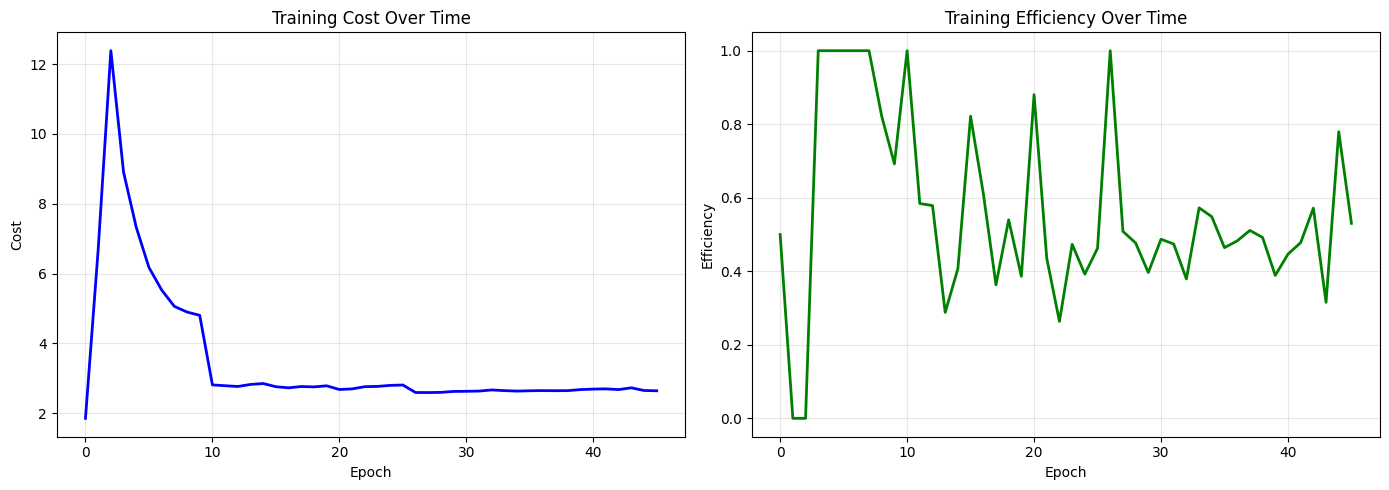

Saved training_history.png


In [ ]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost history
axes[0].plot(metrics.cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cost')
axes[0].set_title('Training Cost Over Time')
axes[0].grid(True, alpha=0.3)

# Efficiency history
axes[1].plot(metrics.efficiency_history, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Efficiency')
axes[1].set_title('Training Efficiency Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved training_history.png")

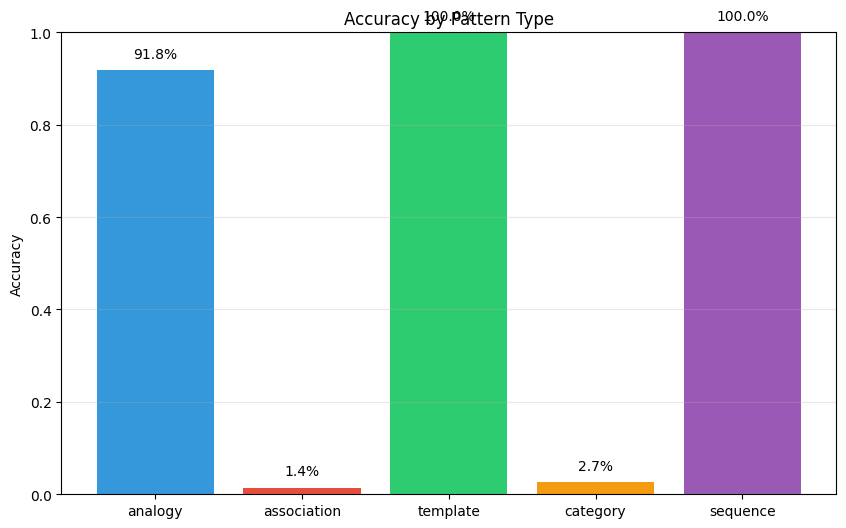

Saved pattern_accuracy.png


In [ ]:
# Per-pattern accuracy visualization
if 'per_pattern' in results:
    patterns = list(results['per_pattern'].keys())
    accuracies = [results['per_pattern'][p]['accuracy'] for p in patterns]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(patterns, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
    plt.ylabel('Accuracy')
    plt.title('Accuracy by Pattern Type')
    plt.ylim(0, 1)
    
    # Add value labels
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=10)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.savefig('./pattern_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved pattern_accuracy.png")

## 10. Summary

In [ ]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  Total samples:     {NUM_SAMPLES:,}")
print(f"  Training samples:  {len(train_inputs):,}")
print(f"  Validation samples: {len(val_inputs):,}")
print(f"  Test samples:      {len(test_inputs):,}")

print(f"\nModel:")
print(f"  Input vocab size:  {tokenizer.input_vocab_size:,}")
print(f"  Output vocab size: {tokenizer.output_vocab_size:,}")
print(f"  Network layers:    {health['current_layers']}")
print(f"  Network nodes:     {health['current_nodes']}")

print(f"\nTraining:")
print(f"  Epochs:            {metrics.epochs_completed}")
print(f"  Training time:     {metrics.training_time_ms / 1000:.2f}s")
print(f"  Final cost:        {metrics.final_cost:.4f}")

print(f"\nTest Performance:")
print(f"  Exact accuracy:    {results['exact_accuracy']:.2%}")
print(f"  Top-3 accuracy:    {results['top3_accuracy']:.2%}")
print(f"  Top-5 accuracy:    {results['top5_accuracy']:.2%}")
print(f"  Perplexity:        {results['perplexity']:.2f}")

print("\n" + "=" * 60)


TRAINING SUMMARY

Dataset:
  Total samples:     100,000
  Training samples:  80,000
  Validation samples: 10,000
  Test samples:      10,000

Model:
  Input vocab size:  434
  Output vocab size: 350
  Network layers:    2
  Network nodes:     358

Training:
  Epochs:            46
  Training time:     112.46s
  Final cost:        2.6454

Test Performance:
  Exact accuracy:    59.32%
  Top-3 accuracy:    60.70%
  Top-5 accuracy:    62.15%
  Perplexity:        13.92

